#  Explore Level 1 DKIST Inventory - Metrics 

Tom Schad | tschad@nso.edu 

**Description** This notebook uses the DKIST user tools to query the entire Level 1 data holdings in the DKIST inventory.  Simple plots are created to explore trends and characteristics, such as: 
* Total data volume versus time and instrument
* Dataset size per instrument and experiment IDs
* Pie graphs of conditions
* Number of files
* and more


In [1]:
import os 
import sys 
import glob
import numpy as np
import pandas as pd 
from tqdm.auto import trange

import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation
from astropy.time import Time
from zoneinfo import ZoneInfo   ## Time zones 

import dkist
import dkist.net
from sunpy.net import Fido, attrs as a
from sunpy.coordinates import frames
from astropy.coordinates import get_sun, EarthLocation, AltAz
from astropy.coordinates import SkyCoord, EarthLocation, AltAz,CartesianRepresentation

import matplotlib.pyplot as plt
%matplotlib inline 
import matplotlib.dates as mdates
from matplotlib.colors import PowerNorm
#### Change to widget backend if desired: %matplotlib widget
plt.rcParams["figure.dpi"] = 120
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams["image.origin"] = 'lower'
plt.rcParams["image.cmap"] = 'gray'
plt.rcParams["image.interpolation"] = 'nearest'
plt.rcParams["font.family"] = "Arial"
plt.rcParams["lines.linewidth"] = 0.7
plt.rcParams['xtick.labelsize']= 9
plt.rcParams['ytick.labelsize']= 9

## Query the DKIST Inventory for all Datasets 

**More information:**  The DKIST datacenter manages a REST API at https://api.dkistdc.nso.edu/datasets/v1  that provides an inventory of each dataset in the DKIST holdings.  Each row of that inventory corresponds to one "Dataset" that results, typically, from one detector of one instrument acquired as part of an "Instrument Program" that is executed as a "Observing Program."  Every time an Observing Program is run, it is tag with a unique execution id.  Datasets meanwhile are tagged with a "Dataset ID' that is unique to the calibration run that produced the dataset.  A unique set of raw science observations that are used to create a "Dataset" are given a "Product ID".  After recalibration of a unique set of science frames, the "Product ID" remains constant whereas the "Dataset ID" will change. 

In [2]:
## This loop grabs all items in the DKIST inventory be querying all pages of data in inventory 
page_length = 1  ## a
page = 0 
dkist_inventory = []
while page_length >0: 
    page += 1
    print(f"Searching DKIST Inventory Page {page}")
    res = Fido.search(a.dkist.Page(page))
    dkist_inventory.extend(res['dkist'])
    page_length = len(res['dkist'])

## After download, we put the inventory into a pandas dataframe and resort by the starttime of the dataset 
rows_as_dicts = [dict(row) for row in dkist_inventory]
# Create a DataFrame
dkist_inventory = pd.DataFrame(rows_as_dicts)
ndatasets = len(dkist_inventory)
print(f" Number of DKIST Datasets in Inventory: {ndatasets}")

dkist_inventory['Start Time'] = dkist_inventory['Start Time'].apply(lambda t: t.datetime)
dkist_inventory['End Time'] = dkist_inventory['End Time'].apply(lambda t: t.datetime)
dkist_inventory = dkist_inventory.sort_values('Start Time').reset_index(drop=True)

Searching DKIST Inventory Page 1
Searching DKIST Inventory Page 2
Searching DKIST Inventory Page 3
Searching DKIST Inventory Page 4
Searching DKIST Inventory Page 5
Searching DKIST Inventory Page 6
Searching DKIST Inventory Page 7
Searching DKIST Inventory Page 8
Searching DKIST Inventory Page 9
Searching DKIST Inventory Page 10
Searching DKIST Inventory Page 11
 Number of DKIST Datasets in Inventory: 3000


## View Dataset Volumes versus Time

- Let's look at the size in Gigabytes of each dataset and their cummulative growth over time for DKIST and for each instrument separately.
- Note that the inventory only contains datasets that have been fully processed.  The volumes here are the compressed L1 data quantities, which is 10 to 100 times less than the raw data volume. 

In [3]:
dataset_size_GB = np.array([d.to(u.Gbyte).value for d in dkist_inventory['Dataset Size']])
insts = np.unique(dkist_inventory['Instrument'])
print(f" List of Unique Instrument Names in Inventory: {insts}")

 List of Unique Instrument Names in Inventory: ['CRYO-NIRSP' 'DL-NIRSP' 'VBI' 'VISP']


In [4]:
inst_colors = {
    'VISP':       '#65b465',  # medium pastel green
    'VBI':        '#6493d1',  # medium pastel blue
    'CRYO-NIRSP': '#e36a63',  # medium pastel red
    'DL-NIRSP':   '#b9bb58'   # medium pastel olive
}

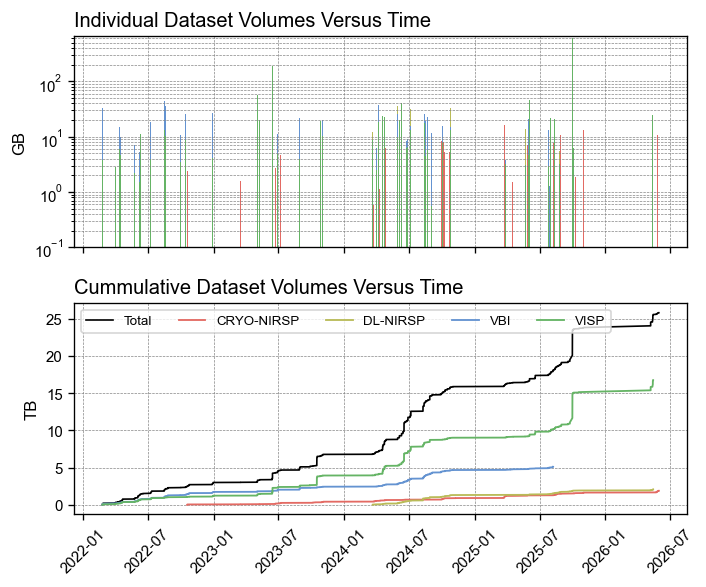

In [5]:
fig,ax = plt.subplots(2,1,figsize = (6,5),sharex=True)
ax = ax.flatten()

ax[1].plot(dkist_inventory['Start Time'],np.cumsum(dataset_size_GB)/1024.,label = 'Total',lw = 1,color = 'black')
for inst in insts: 
    ww = (dkist_inventory['Instrument'] == inst)
    ax[0].bar(dkist_inventory['Start Time'][ww],dataset_size_GB[ww],color = inst_colors[inst],lw = 1)
    ax[1].plot(dkist_inventory['Start Time'][ww],np.cumsum(dataset_size_GB[ww])/1024.,label = inst,lw = 1.1,color = inst_colors[inst])
ax[1].legend(ncol = 5,fontsize = 8,loc = 'upper left')
ax[0].set_title("Individual Dataset Volumes Versus Time",loc = 'left')
ax[1].set_title("Cummulative Dataset Volumes Versus Time",loc = 'left')
ax[0].set_ylabel("GB")
ax[1].set_ylabel("TB")

ax[0].set_yscale('log')
ax[0].set_ylim(0.1,dataset_size_GB.max()*1.1)
ax[0].grid(which='both',ls = 'dashed',color = 'grey',lw = 0.4) 
ax[1].grid(ls = 'dashed',color = 'grey',lw = 0.4) 

date_format = mdates.DateFormatter('%Y-%m')  # e.g., "Jan 01, 2023"
ax[1].xaxis.set_major_formatter(date_format)
ax[1].tick_params(axis='x', rotation=45)

fig.tight_layout()

## Pie Chart of Data Volumes by Instrument and by Experiment 

In [6]:
total_data_by_instrument = []
for inst in insts: 
    ww = (dkist_inventory['Instrument'] == inst)
    total_data_by_instrument.append(np.sum(dataset_size_GB[ww]))

total_data_by_experiment = []
experiments = np.unique(dkist_inventory['Primary Experiment ID'].values)
for eid in experiments: 
    ww = (dkist_inventory['Primary Experiment ID'] == eid)
    total_data_by_experiment.append(np.sum(dataset_size_GB[ww]))

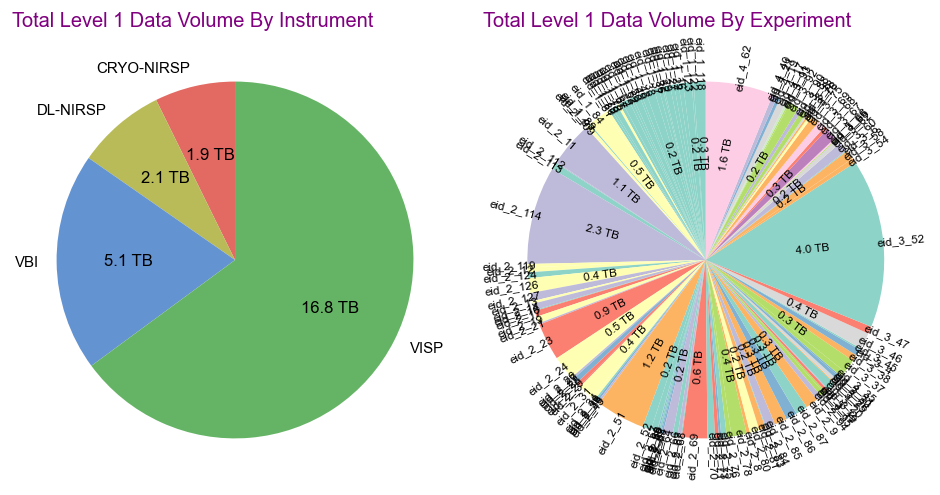

In [7]:
fig,ax = plt.subplots(1,2,figsize = (8,5))
ax = ax.flatten()

def value_label(pct, allvals):
    absolute = int(round(pct / 100 * sum(allvals)))
    return f"{(absolute/1024):.1f} TB"

wedges, texts, autotexts = ax[0].pie(
    total_data_by_instrument,
    labels = insts,
    autopct=lambda pct: value_label(pct, total_data_by_instrument),
    colors = [inst_colors[inst] for inst in insts],
    startangle=90
)
ax[0].set_aspect('equal')

cmap = plt.cm.Set3  # Choose a colormap
color_indices = np.linspace(0, 1, len(experiments))
colors = cmap(color_indices)
import random
random.shuffle(colors) 

def value_label(pct, allvals):
    absolute = int(round(pct / 100 * sum(allvals)))
    if absolute > 200: return f"{(absolute)/1000:.1f} TB"
    return f""

wedges, texts,autotext = ax[1].pie(
    total_data_by_experiment,
    labels = experiments,
    colors = colors,
    autopct=lambda pct: value_label(pct, total_data_by_instrument),
    startangle=90
)
for autotxt, text, wedge in zip(autotext,texts, wedges):
    # compute the wedge’s mid‐angle
    angle = (wedge.theta2 + wedge.theta1) / 2
    # if on left‐half, flip by 180°
    if 90 < angle < 270:
        rotation = angle + 180
    else:
        rotation = angle
    text.set_rotation(rotation)
    text.set_horizontalalignment('center')
    text.set_verticalalignment('center')
    text.set_fontsize(7)
    autotxt.set_rotation(rotation)
    autotxt.set_horizontalalignment('center')
    autotxt.set_verticalalignment('center')
    autotxt.set_fontsize(7)


ax[1].set_aspect('equal')
ax[0].set_title("Total Level 1 Data Volume By Instrument",loc = 'left',color = 'purple')
ax[1].set_title("Total Level 1 Data Volume By Experiment",loc = 'left',color = 'purple')

fig.tight_layout()

## Plot the Dataset Coverage by Time of Day for Each Dataset

- Here we also calculate the sunrise and sunset times for DKIST as calculated by when the sun is at 7 degrees above the horizon, which is related to the DKIST telescope pointing limitations.

In [8]:
def location_of_dkist():
    return EarthLocation(lat=20.7067*u.deg, lon=-156.2566*u.deg, height=3055*u.m)

def get_sunrise_sunset_times_by_year(year,days = np.arange(0,365,5)): 
    
    sun_7deg_times = np.zeros((3,len(days)))
    sun_7deg_times[0,:] = days 
    for d in trange(len(days)):   ## every five days 
        day = days[d] 
        t_midnight = Time(f"{year}-01-01T10:00:00") + day*u.day
        obs_times = Time(f"{year}-01-01T15:00:00") + day*u.day + np.linspace(0,4,100)*u.hr
    
        altaz_frame = AltAz(obstime=obs_times, location=location_of_dkist())
        sun_altaz = get_sun(obs_times).transform_to(altaz_frame)
    
        wmin = np.argmin(abs(sun_altaz.alt.deg - 7.))
        tt = obs_times[wmin]
        dt = tt.to_datetime() - t_midnight.to_datetime()
        sun_7deg_times[1,d] = dt.total_seconds()
    
        obs_times = Time(f"{year}-01-01T15:00:00") + day*u.day + 12*u.hr + np.linspace(0,4,100)*u.hr
        altaz_frame = AltAz(obstime=obs_times, location=location_of_dkist())
        sun_altaz = get_sun(obs_times).transform_to(altaz_frame)
        wmin = np.argmin(abs(sun_altaz.alt.deg - 7.))
        tt = obs_times[wmin]
        dt = tt.to_datetime() - t_midnight.to_datetime()
        sun_7deg_times[2,d] = dt.total_seconds()
        
    return sun_7deg_times


sun_7deg_2022 = get_sunrise_sunset_times_by_year(2022)
sun_7deg_2023 = get_sunrise_sunset_times_by_year(2023)
sun_7deg_2024 = get_sunrise_sunset_times_by_year(2024)
sun_7deg_2025 = get_sunrise_sunset_times_by_year(2025)
sun_7deg_2026 = get_sunrise_sunset_times_by_year(2026)

  0%|          | 0/73 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

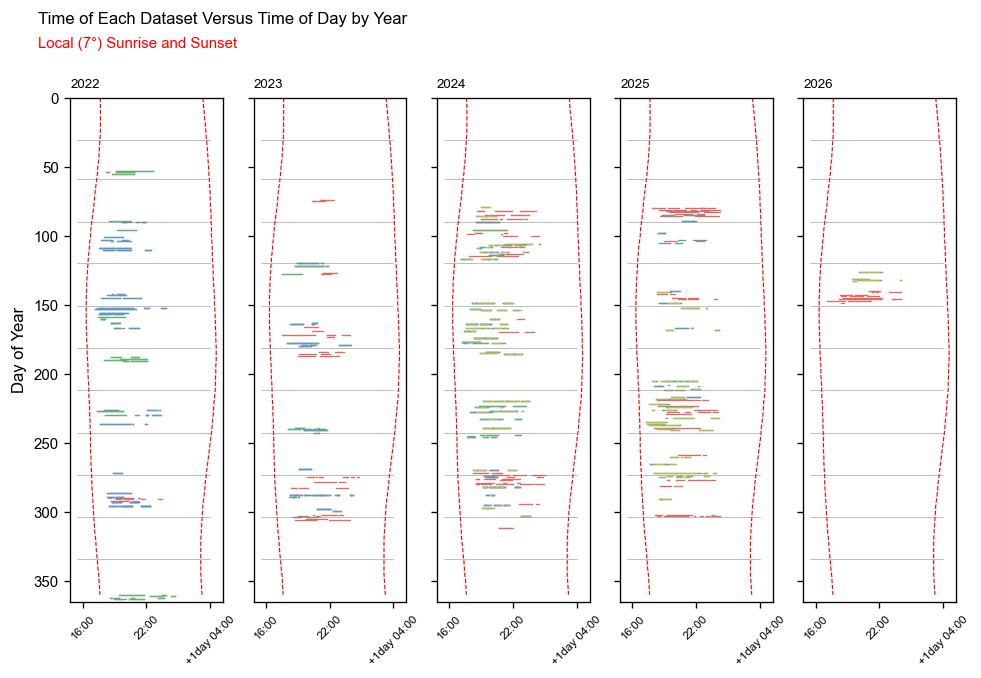

In [9]:
fig,ax = plt.subplots(1,5,figsize = (9,6),sharex=True,sharey=True) 
ax = ax.flatten()

titles = '2022','2023','2024','2025','2026',
sun_7deg_data = (sun_7deg_2022,sun_7deg_2023,sun_7deg_2024,sun_7deg_2025,sun_7deg_2026)
for n in range(5): 
    ax[n].plot(sun_7deg_data[n][1,:],sun_7deg_data[n][0,:], label='Sunrise (7°)', color='red',lw = 0.7,ls = 'dashed')
    ax[n].plot(sun_7deg_data[n][2,:],sun_7deg_data[n][0,:], label='Sunset (7°)', color='red',lw = 0.7,ls = 'dashed')
    ax[n].invert_yaxis()
    ax[n].set_title(titles[n],loc = 'left',fontsize = 8)

ax[0].set_ylabel("Day of Year")
ax[0].set_ylim(365,0)

for n in range(len(dkist_inventory)):
    t0,t1 = dkist_inventory.iloc[n]['Start Time'],dkist_inventory.iloc[n]['End Time']
    t0 = t0.replace(tzinfo=ZoneInfo("UTC")).astimezone(ZoneInfo("US/Hawaii"))
    t1 = t1.replace(tzinfo=ZoneInfo("UTC")).astimezone(ZoneInfo("US/Hawaii"))
    tmid = t0.replace(hour=0,minute = 0,second = 0,microsecond=0)
    doy =  (t0 - t0.replace(month = 1,day = 1, hour=0,minute = 0,second = 0,microsecond=0)).days

    inst = dkist_inventory.iloc[n]['Instrument']
    
    if t0.year == 2022: ax[0].plot([(t0-tmid).total_seconds(),(t1-tmid).total_seconds()],[doy,doy],color = inst_colors[inst])
    if t0.year == 2023: ax[1].plot([(t0-tmid).total_seconds(),(t1-tmid).total_seconds()],[doy,doy],color = inst_colors[inst])
    if t0.year == 2024: ax[2].plot([(t0-tmid).total_seconds(),(t1-tmid).total_seconds()],[doy,doy],color = inst_colors[inst])
    if t0.year == 2025: ax[3].plot([(t0-tmid).total_seconds(),(t1-tmid).total_seconds()],[doy,doy],color = inst_colors[inst])
    if t0.year == 2026: ax[4].plot([(t0-tmid).total_seconds(),(t1-tmid).total_seconds()],[doy,doy],color = inst_colors[inst])

for axi in ax: 
    axi.set_xticks(np.array([6,12,18])*60*60)
    axi.set_xticklabels(["16:00","22:00","+1day 04:00"],rotation = 45,fontsize = 7)

import datetime
for month in range(1,13): 
        t0 = datetime.datetime(2023,month,1,0,0,0,0)
        doy =  (t0 - t0.replace(month = 1,day = 1, hour=0,minute = 0,second = 0,microsecond=0)).days
        for axi in ax: 
            axi.plot([5.5*60*60,18*60*60],[doy,doy],ls = 'solid',lw = 0.3,color = 'grey')

fig.text(0.1,0.97,'Time of Each Dataset Versus Time of Day by Year',ha = 'left',va = 'top',fontsize = 10)
fig.text(0.1,0.935,'Local (7°) Sunrise and Sunset',color = 'red',ha = 'left',va = 'top',fontsize = 9)

fig.subplots_adjust(0.13,0.15,0.95,0.85)

## Plot The Cummulative Number of Frames by Time and Instrument


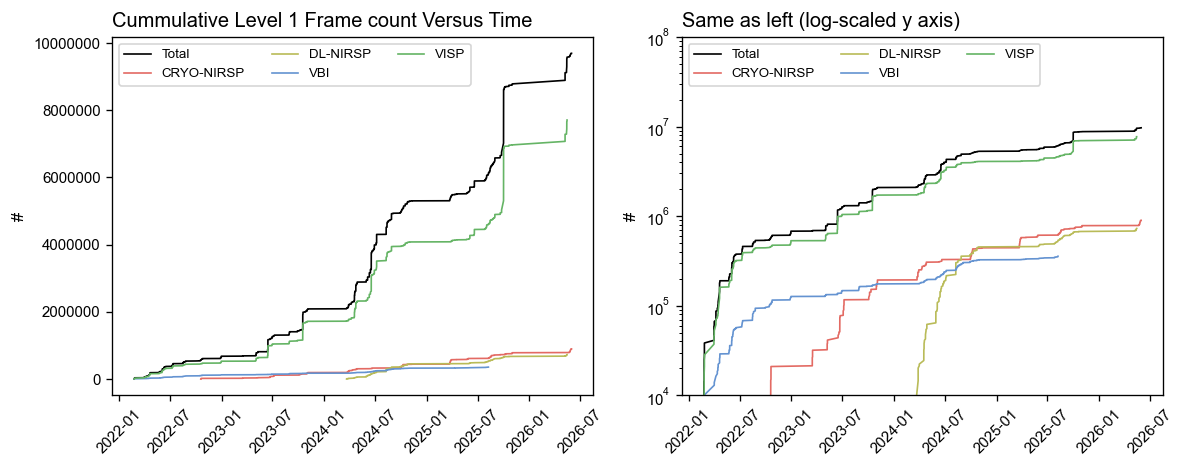

In [10]:
fig,ax = plt.subplots(1,2,figsize = (10,4),sharex=True)
ax = ax.ravel()
for n in 0,1,: 
    ax[n].plot(dkist_inventory['Start Time'],np.cumsum(dkist_inventory['Level 0 Frame count']),label = 'Total',lw = 1,color = 'black')
    for inst in insts: 
        ww = (dkist_inventory['Instrument'] == inst)
        ax[n].plot(dkist_inventory['Start Time'][ww],np.cumsum(dkist_inventory['Number of Frames'][ww]),color = inst_colors[inst],lw = 1,label = inst)
    ax[n].legend(ncol = 3,fontsize = 8,loc = 'upper left')
    
    ax[n].set_ylabel("#")
    if n == 0: 
        ax[n].set_title("Cummulative Level 1 Frame count Versus Time",loc = 'left')
        ax[n].ticklabel_format(axis='y', style='plain', useOffset=False)
    else: 
        ax[n].set_yscale('log')
        ax[n].set_title("Same as left (log-scaled y axis)",loc = 'left')
        ax[n].set_ylim(1e4,1.e8)
    date_format = mdates.DateFormatter('%Y-%m')  # e.g., "Jan 01, 2023"
    ax[n].xaxis.set_major_formatter(date_format)
    ax[n].tick_params(axis='x', rotation=45)

fig.tight_layout()

## Pie Charts of Total Observing Time by Experiment 

In [11]:
total_time_by_opid = []
opids = np.unique(dkist_inventory['Observing Program Execution ID'].values)
for opid in opids: 
    ww = np.where((dkist_inventory['Observing Program Execution ID'] == opid))[0]
    minTime = np.min(dkist_inventory['Start Time'][ww])
    maxTime = np.max(dkist_inventory['End Time'][ww])
    totTime = (maxTime - minTime).total_seconds()/60./60.  ## hours 
    total_time_by_opid.append(totTime)

total_time_by_opid = np.array(total_time_by_opid)
total_time_by_experiment = []
eids_of_opids = np.array([opid.split('_op')[0] for opid in opids])
experiments = np.unique(eids_of_opids)
for eid in experiments: 
    totTime = np.sum(total_time_by_opid[np.where(eids_of_opids == eid)[0]])
    total_time_by_experiment.append(totTime)

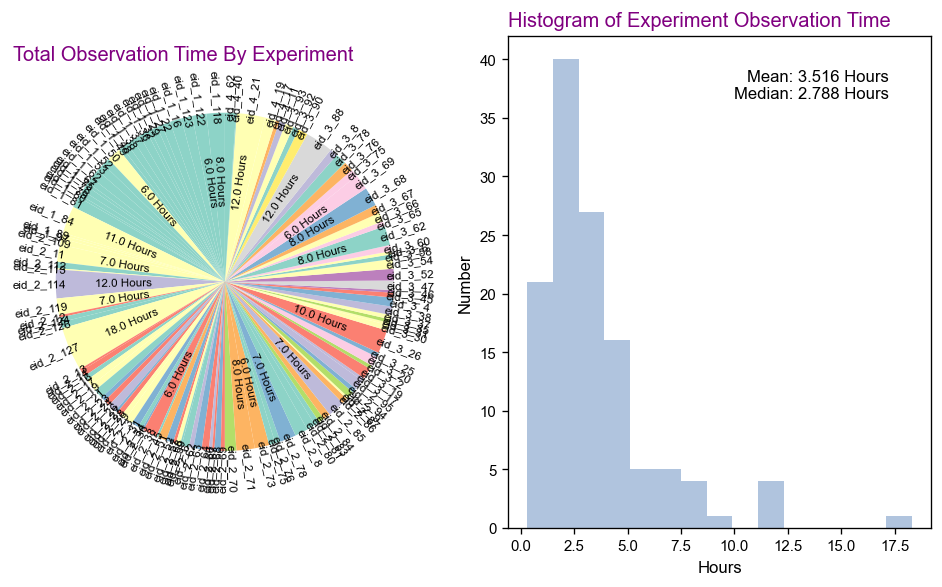

In [12]:
fig,ax = plt.subplots(1,2,figsize = (8,5))
ax = ax.flatten()
cmap = plt.cm.Set3  # Choose a colormap
color_indices = np.linspace(0, 1, len(experiments))
colors = cmap(color_indices)
import random
random.shuffle(colors) 

def value_label(pct, allvals):
    absolute = int(round(pct / 100 * sum(allvals)))
    if absolute > 5: return f"{(absolute):.1f} Hours"
    return f""

wedges, texts,autotext = ax[0].pie(
    total_time_by_experiment,
    labels = experiments,
    colors = colors,
    autopct=lambda pct: value_label(pct, total_time_by_experiment),
    startangle=90
)
for autotxt, text, wedge in zip(autotext,texts, wedges):
    # compute the wedge’s mid‐angle
    angle = (wedge.theta2 + wedge.theta1) / 2
    # if on left‐half, flip by 180°
    if 90 < angle < 270:
        rotation = angle + 180
    else:
        rotation = angle
    text.set_rotation(rotation)
    text.set_horizontalalignment('center')
    text.set_verticalalignment('center')
    text.set_fontsize(7)
    autotxt.set_rotation(rotation)
    autotxt.set_horizontalalignment('center')
    autotxt.set_verticalalignment('center')
    autotxt.set_fontsize(7)


ax[0].set_aspect('equal')
ax[0].set_title("Total Observation Time By Experiment",loc = 'left',color = 'purple')

ax[1].hist(total_time_by_experiment,bins = 15,color = 'lightsteelblue')
ax[1].set_title("Histogram of Experiment Observation Time",loc = 'left',color = 'purple')
ax[1].set_xlabel("Hours")
ax[1].set_ylabel("Number")
ax[1].text(0.9,0.9,f'Mean: {np.nanmean(total_time_by_experiment):.3f} Hours\nMedian: {np.nanmedian(total_time_by_experiment):.3f} Hours',ha = 'right',va = 'center',transform = ax[1].transAxes)

fig.tight_layout()

## Average Effective Level 1 Data Rate by Experiment 

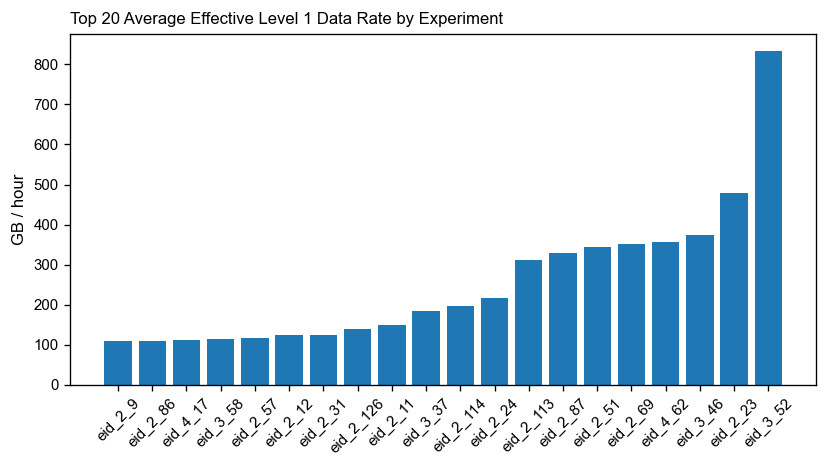

In [13]:
data_rate_by_experiment = np.asarray(total_data_by_experiment) / np.asarray(total_time_by_experiment)
fig, ax = plt.subplots(1,1,figsize = (7,4)) 
ax =  np.asarray(ax).reshape(-1)
w_largest_rates = np.argsort(data_rate_by_experiment)[-20:]
ax[0].bar(experiments[w_largest_rates],data_rate_by_experiment[w_largest_rates])
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_ylabel("GB / hour")
ax[0].set_title("Top 20 Average Effective Level 1 Data Rate by Experiment",loc = 'left',fontsize = 10)
fig.tight_layout()

## ViSP Wavelengths 

In [14]:
Spectral_Lines = []
for values in dkist_inventory['Spectral Lines']:
    if isinstance(values, list):
        for value in values: 
            Spectral_Lines.append(value)

In [15]:
ww = (dkist_inventory['Instrument'] == 'VBI')
vbi_wavelengths = []
for dd in dkist_inventory['Wavelength'][ww]: 
    vbi_wavelengths.append(f"{dd[0].value} nm")

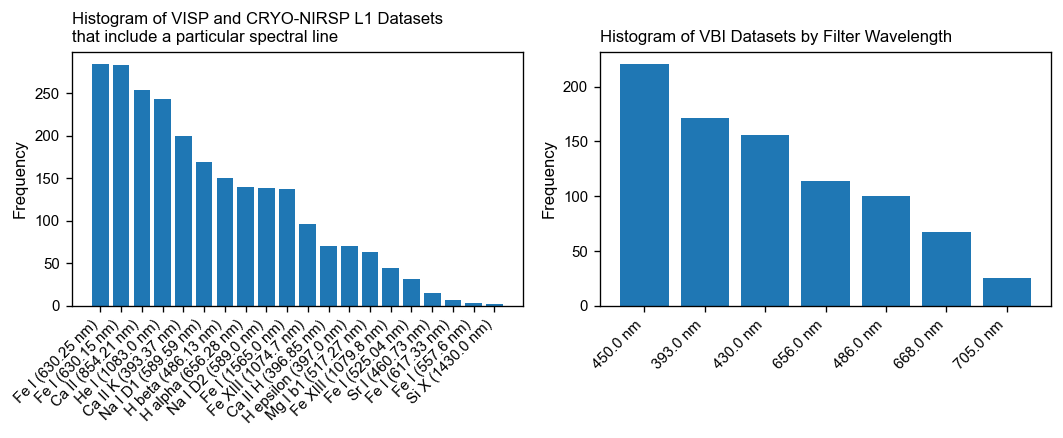

In [16]:
line_counts = pd.Series(Spectral_Lines).value_counts()

fig, ax = plt.subplots(1, 2, figsize=(9,3.75))
ax = ax.flatten()
ax[0].bar(line_counts.index, line_counts.values)
ax[0].set_ylabel("Frequency")
ax[0].set_title("Histogram of VISP and CRYO-NIRSP L1 Datasets\nthat include a particular spectral line",loc = 'left',fontsize = 10)
plt.setp(ax[0].get_xticklabels(), rotation=45, ha='right')

line_counts = pd.Series(vbi_wavelengths).value_counts()
ax[1].bar(line_counts.index, line_counts.values)
ax[1].set_ylabel("Frequency")
ax[1].set_title("Histogram of VBI Datasets by Filter Wavelength",loc = 'left',fontsize = 10)
plt.setp(ax[1].get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()

In [17]:
np.unique(Spectral_Lines)

array(['Ca II (854.21 nm)', 'Ca II H (396.85 nm)', 'Ca II K (393.37 nm)',
       'Fe I (1565.0 nm)', 'Fe I (525.04 nm)', 'Fe I (557.6 nm)',
       'Fe I (617.33 nm)', 'Fe I (630.15 nm)', 'Fe I (630.25 nm)',
       'Fe XIII (1074.7 nm)', 'Fe XIII (1079.8 nm)',
       'H alpha (656.28 nm)', 'H beta (486.13 nm)',
       'H epsilon (397.0 nm)', 'He I (1083.0 nm)', 'Mg I b1 (517.27 nm)',
       'Na I D1 (589.59 nm)', 'Na I D2 (589.0 nm)', 'Si X (1430.0 nm)',
       'Sr I (460.73 nm)'], dtype='<U20')

## Lets grab and embed some vimeo videos for a single dataset

In [18]:
from IPython.display import HTML
product_id = 'L1-ZUEBA'
wdataset = np.where(dkist_inventory['Product ID'] == f"{product_id}")[0][0]
vimeo_id = dkist_inventory['Preview URL'][wdataset].split('/')[-1]
HTML(f"""
<iframe src="https://player.vimeo.com/video/{vimeo_id}" width="640" height="360" frameborder="0"
allow="autoplay; fullscreen; picture-in-picture" allowfullscreen></iframe>
""")

## Now get all videos for the same Observing Program based on a single dataset 

In [19]:
from IPython.display import HTML
import numpy as np
product_id = 'L1-ZUEBA'
wdataset = np.where(dkist_inventory['Product ID'] == f"{product_id}")[0][0]
where_same_opid = np.where(dkist_inventory['Observing Program Execution ID'] == dkist_inventory['Observing Program Execution ID'][wdataset])[0]

html_string = "<table>"
for i, wdataset in enumerate(where_same_opid):    
    vimeo_id = dkist_inventory['Preview URL'][wdataset].split('/')[-1]
    text = f"Observing Program: {dkist_inventory['Observing Program Execution ID'][wdataset]}<br>"
    text += f"Instrument: {dkist_inventory['Instrument'][wdataset]}<br>"
    text += f"Start time: {dkist_inventory['Start Time'][wdataset]}<br>"
    text += f"Wavelength Min: {dkist_inventory['Wavelength'][wdataset][0]:.3f}<br>"
    text += f"Wavelength Max: {dkist_inventory['Wavelength'][wdataset][1]:.3f}<br>"
    html_string += f"""
    <tr>
        <td style="vertical-align: top; padding: 10px; text-align: left;">{text}</td>
        <td style="padding: 10px;">
            <iframe src="https://player.vimeo.com/video/{vimeo_id}" width="640" height="360" frameborder="0"
            allow="autoplay; fullscreen; picture-in-picture" allowfullscreen></iframe>
        </td>
    </tr>
    """

html_string += "</table>"

HTML(html_string)

Observing Program: eid_2_114_opNcs9Cj_R003.150682.24171305Instrument: VBIStart time: 2024-04-27 19:42:05.336748Wavelength Min: 450.000 nmWavelength Max: 450.000 nm,
Observing Program: eid_2_114_opNcs9Cj_R003.150682.24171305Instrument: VISPStart time: 2024-04-27 19:42:08.688000Wavelength Min: 629.535 nmWavelength Max: 630.708 nm,
Observing Program: eid_2_114_opNcs9Cj_R003.150682.24171305Instrument: VISPStart time: 2024-04-27 19:42:08.712500Wavelength Min: 588.936 nmWavelength Max: 590.204 nm,
Observing Program: eid_2_114_opNcs9Cj_R003.150682.24171305Instrument: VISPStart time: 2024-04-27 19:42:08.712500Wavelength Min: 853.190 nmWavelength Max: 854.952 nm,
Observing Program: eid_2_114_opNcs9Cj_R003.150682.24171305Instrument: DL-NIRSPStart time: 2024-04-27 19:42:20.878000Wavelength Min: 1082.428 nmWavelength Max: 1083.501 nm,
